In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.DataFrame(pd.read_csv('heart_disease.csv'))

In [4]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [7]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
age,1.000000,0.009521,0.093749,0.300976,0.216582,0.039471,0.103289,-0.418977,0.076624,0.211922,0.104509,0.181747,0.082420,0.216431,0.217659
sex,0.009521,1.000000,0.054375,0.042447,-0.023312,0.012140,0.007685,-0.081918,0.098694,0.082873,0.082668,0.105479,0.239343,0.274200,0.294585
cp,0.093749,0.054375,1.000000,0.050346,0.091502,-0.054847,0.086757,-0.207494,0.281380,0.151299,0.159388,0.227960,0.208169,0.414098,0.419199
trestbps,0.300976,0.042447,0.050346,1.000000,0.163489,0.061876,0.085157,-0.058999,0.012895,0.121276,0.069488,0.102795,0.071504,0.160835,0.159709
chol,0.216582,-0.023312,0.091502,0.163489,1.000000,-0.060612,0.063888,0.009172,0.044399,0.034087,0.003815,0.086070,0.064225,0.094179,0.100516
fbs,0.039471,0.012140,-0.054847,0.061876,-0.060612,1.000000,0.057401,-0.028131,0.047438,0.011266,0.031258,0.038346,0.026443,0.029195,0.018116
restecg,0.103289,0.007685,0.086757,0.085157,0.063888,0.057401,1.000000,-0.076061,0.135027,0.110927,0.088455,0.124232,0.067710,0.194071,0.191569
thalach,-0.418977,-0.081918,-0.207494,-0.058999,0.009172,-0.028131,-0.076061,1.000000,-0.232018,-0.359916,-0.235949,-0.185113,-0.231847,-0.401463,-0.403995
exang,0.076624,0.098694,0.281380,0.012895,0.044399,0.047438,0.135027,-0.232018,1.000000,0.212877,0.138543,0.155472,0.252715,0.408737,0.422439
oldpeak,0.211922,0.082873,0.151299,0.121276,0.034087,0.011266,0.110927,-0.359916,0.212877,1.000000,0.261474,0.218355,0.260469,0.460848,0.432302


In [8]:
data.isna().sum()

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
num              0
target_binary    0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

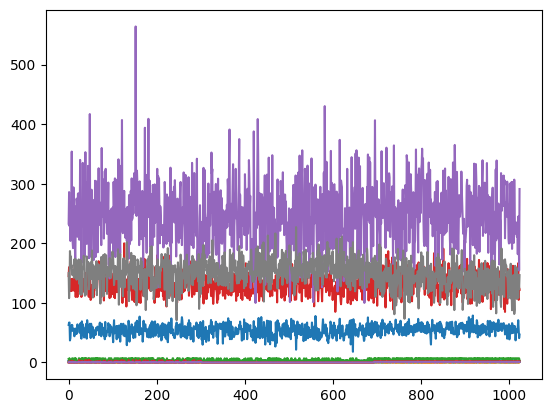

In [10]:
import matplotlib.pyplot as plt; fig, ax = plt.subplots(); ax.plot(data)

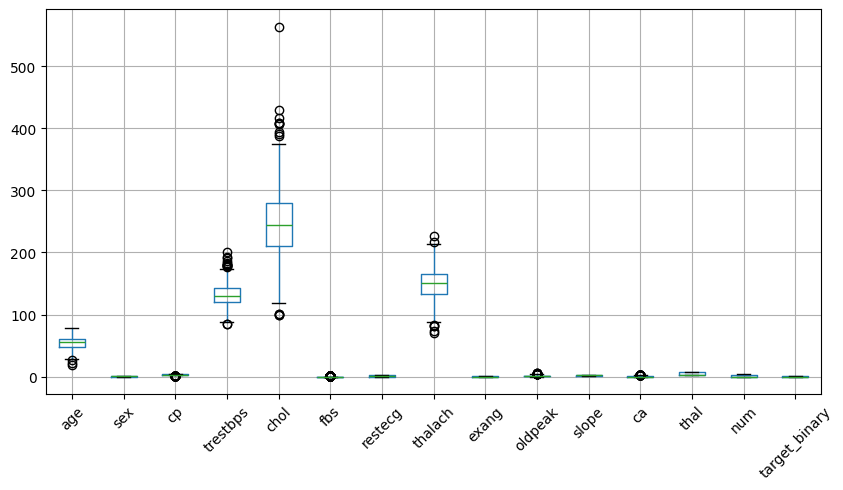

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
data.boxplot()
plt.xticks(rotation=45)
plt.show()

In [12]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
pd.DataFrame(outliers)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1020,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1021,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1022,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [13]:
df_clean = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

In [16]:
for col in data.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    data[col] = data[col].clip(lower, upper)

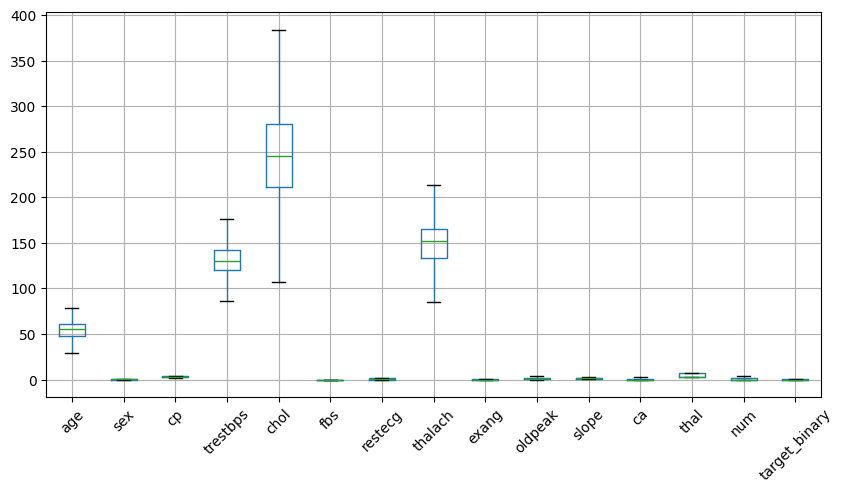

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
data.boxplot()
plt.xticks(rotation=45)
plt.show()

In [31]:
for col in data.columns:
    print(col, data[col].head(4).unique())

age [63. 67. 37.]
sex [1]
cp [1.5 4.  3. ]
trestbps [145. 160. 120. 130.]
chol [233. 286. 229. 250.]
fbs [0]
restecg [2 0]
thalach [150. 108. 129. 187.]
exang [0 1]
oldpeak [2.3 1.5 2.6 3.5]
slope [3 2]
ca [0.  2.5 2. ]
thal [6. 3. 7.]
num [0 2 1]
target_binary [0 1]


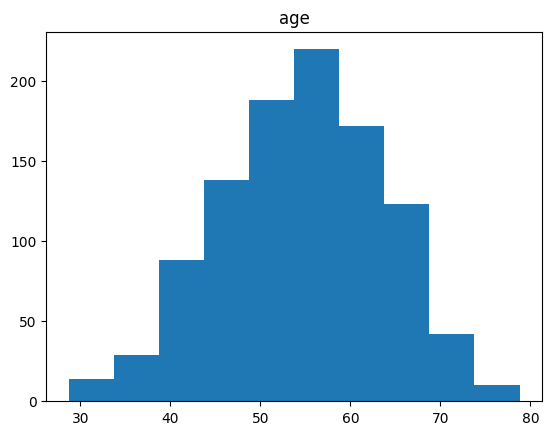

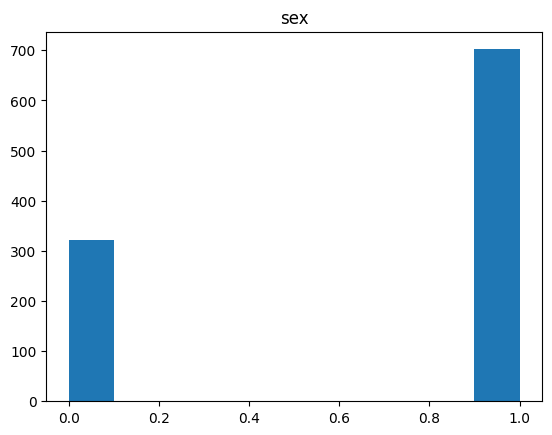

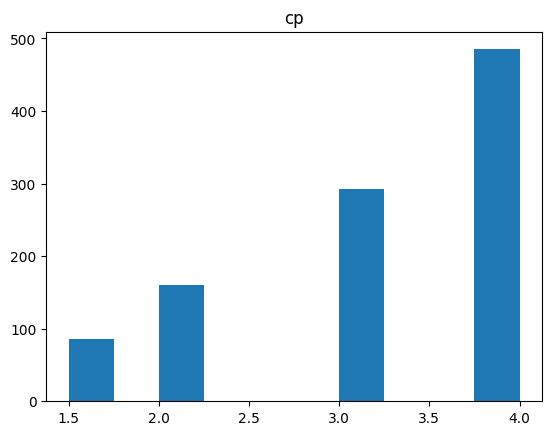

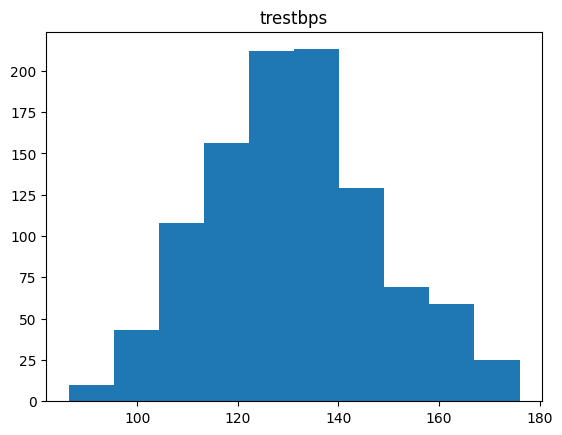

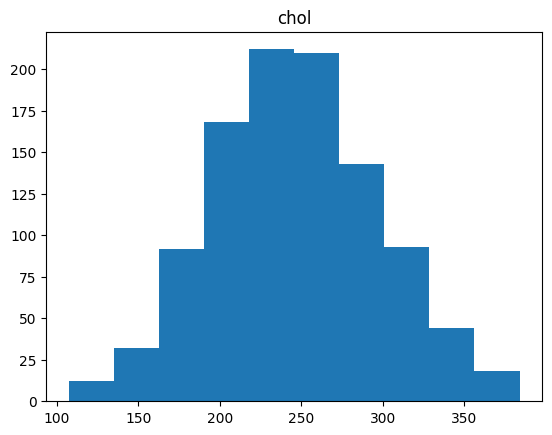

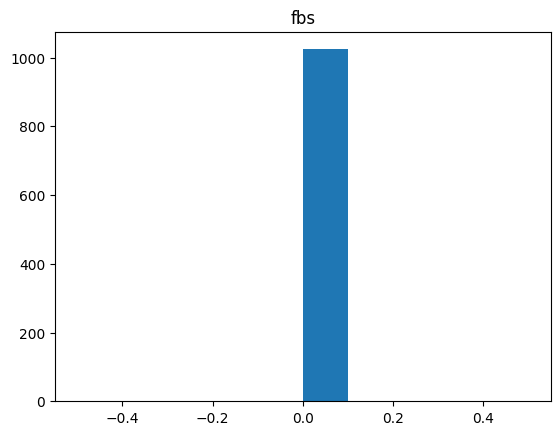

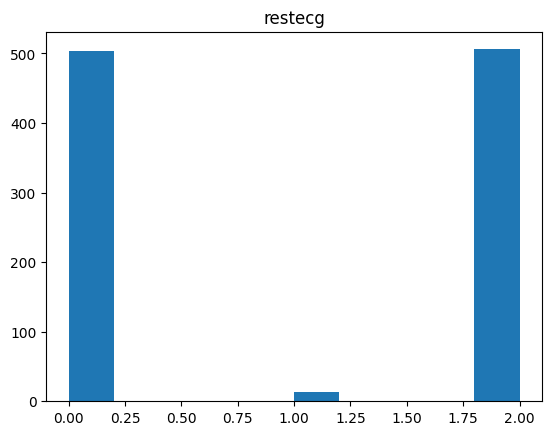

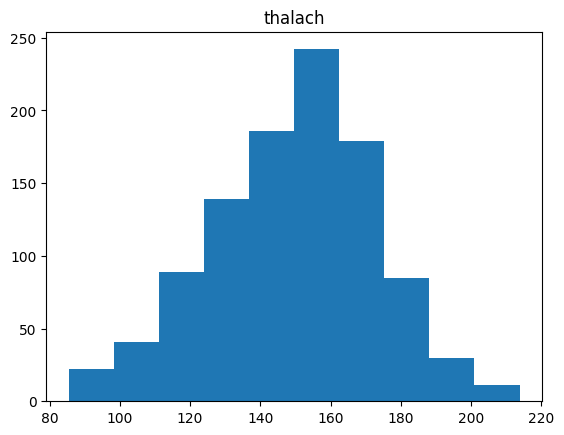

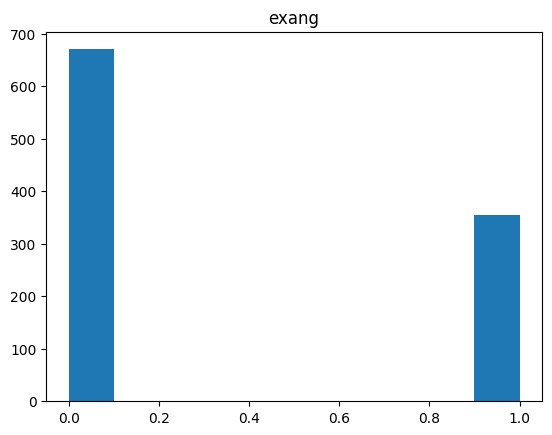

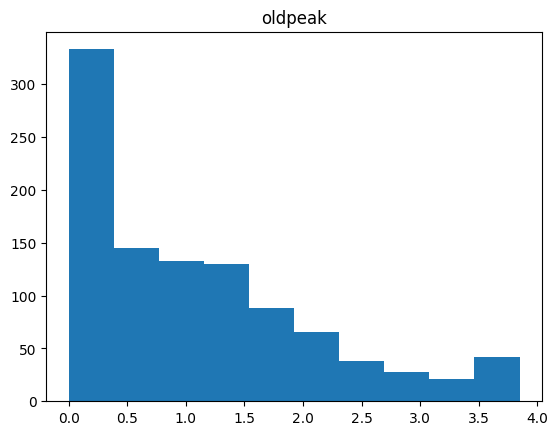

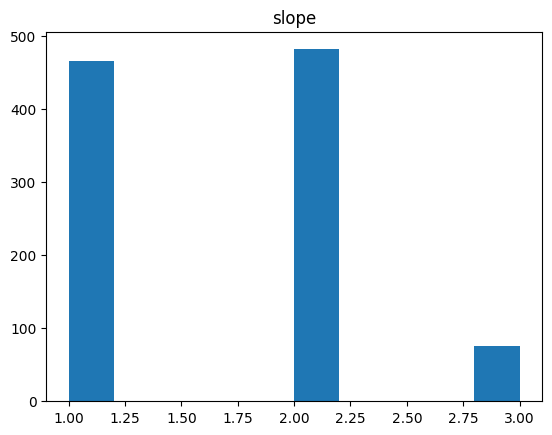

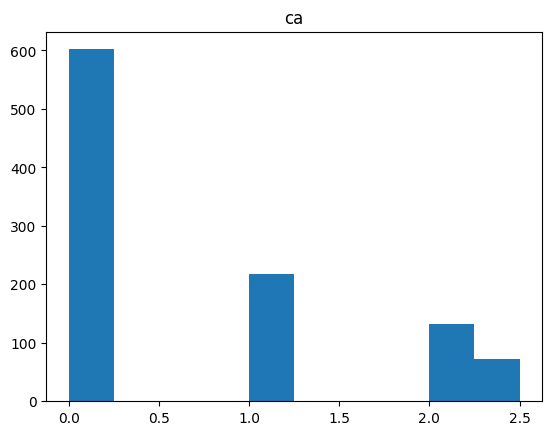

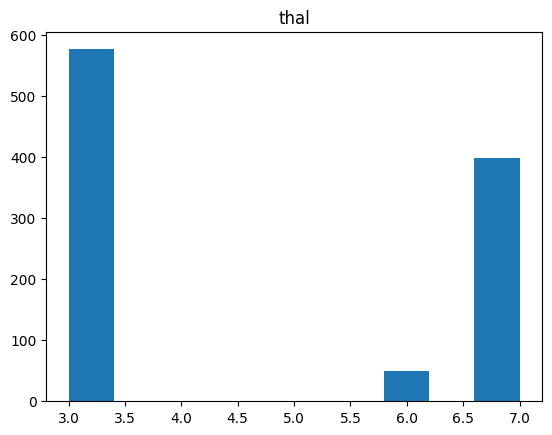

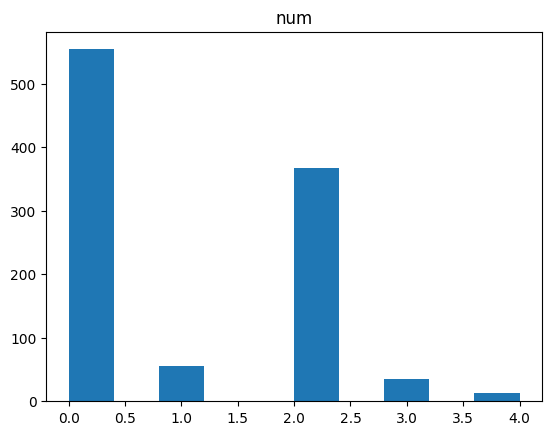

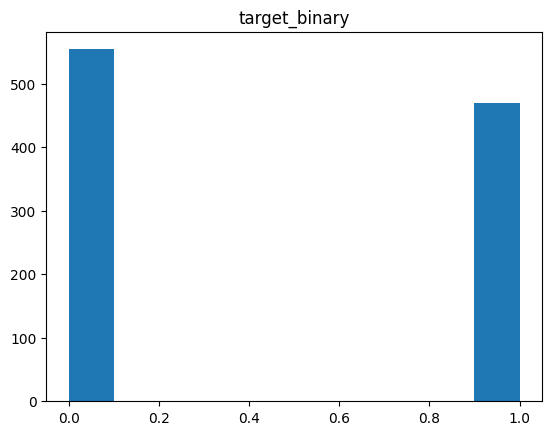

In [36]:
import matplotlib.pyplot as plt

for col in data.columns:
    plt.figure()
    plt.hist(data[col])
    plt.title(col)
    plt.show()

In [37]:
X = data.drop('target_binary',axis=1)
y = data['target_binary']

In [38]:
X.shape

(1024, 14)

In [39]:
y.shape

(1024,)

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_test.shape)

(819, 14)
(205,)


#Model Logistic regression

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9951219512195122

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       113
           1       1.00      0.99      0.99        92

    accuracy                           1.00       205
   macro avg       1.00      0.99      1.00       205
weighted avg       1.00      1.00      1.00       205


Confusion Matrix:
 [[113   0]
 [  1  91]]


In [49]:
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9951219512195122


In [50]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())

CV Scores: [1.         0.99390244 0.99390244 1.         1.        ]
Mean CV Score: 0.9975609756097562


#Model Random Forest

In [53]:
# ── 3. Load & Fit Random Forest ──────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf.fit(X_train, y_train)
print("\nModel trained ✅")

# ── 4. Predict ───────────────────────────────────────────────────────
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

# ── 5. Evaluate ──────────────────────────────────────────────────────
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model trained ✅

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        92

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion Matrix:
[[113   0]
 [  0  92]]


In [54]:
test_acc = accuracy_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_train, y_train, cv=5)

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())
print("Std CV Score:", scores.std())

CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.0
Std CV Score: 0.0
